In [2]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from scipy.special import j1

In [3]:
plt.rcParams['font.family'] = 'Times'
plt.rcParams['mathtext.fontset'] = 'stix'

In [8]:
file = 'lam_lab1_data_30.rad'
with open(file, 'r') as infile, open('radio_1_proc.rad', 'w') as outfile:
    for line in infile:
        if not line.startswith('*'):
            line_proc = ','.join(line.split())
            outfile.write(line_proc + '\n')
        else:
            outfile.write(line)

In [13]:
data = pl.read_csv(
    'radio_1_proc.rad',
    comment_prefix='*',
    has_header=False,
    new_columns=['time', 'az', 'el', 'az_offset', 'el_offset', 'freq_1_bin', 'channel_width', 'spect_mode', 'num_channels'] 
    + [str(x) for x in range(64)]
)

data = data.select(
    pl.col('time'),
    pl.col('az'),
    pl.col('el'),
    pl.col('az_offset'),
    pl.col('el_offset'),
    pl.concat_list(data.columns[9:]).alias('spectrum'),
).tail(-3) # Not sure what was up with the first 3 rows tbh

data

time,az,el,az_offset,el_offset,spectrum
str,f64,f64,f64,f64,list[f64]
"""2025:253:16:44:19""",129.1,48.5,-24.0,0.0,"[38.0, 48.0, … 48.0]"
"""2025:253:16:44:22""",129.1,48.5,-24.0,0.0,"[39.0, 49.0, … 48.0]"
"""2025:253:16:44:24""",129.1,48.5,-24.0,0.0,"[38.0, 47.0, … 48.0]"
"""2025:253:16:44:27""",129.1,48.5,-24.0,0.0,"[39.0, 49.0, … 48.0]"
"""2025:253:16:44:30""",129.1,48.5,-24.0,0.0,"[38.0, 48.0, … 48.0]"
…,…,…,…,…,…
"""2025:253:16:54:54""",180.8,49.4,24.0,0.0,"[40.0, 49.0, … 51.0]"
"""2025:253:16:54:56""",180.8,49.4,24.0,0.0,"[40.0, 49.0, … 49.0]"
"""2025:253:16:54:59""",180.8,49.4,24.0,0.0,"[41.0, 51.0, … 51.0]"


In [15]:
agg_intensities = data.with_columns(
    pl.col('spectrum').list.mean().alias('integrated_intensity')   # Integrated intensity is proportional to the mean of the spectrum
).group_by('az_offset').agg([                                      # Group measurements by offset
    pl.col('integrated_intensity').mean().alias('mean_intensity'), # Mean intensity at each offset
    pl.col('integrated_intensity').std().alias('std_intensity'),   # Stdev intensity at each offset
]).sort(
    pl.col('az_offset')
)

agg_intensities

az_offset,mean_intensity,std_intensity
f64,f64,f64
-24.0,1484.046154,3.584386
-21.0,1490.547476,2.545322
-18.0,1496.458413,3.432754
-15.0,1502.908594,3.728702
-12.0,1501.461058,3.182692
…,…,…
12.0,1519.966146,4.328408
15.0,1501.33774,6.010694
18.0,1485.563341,9.954186


In [16]:
agg_intensities.write_csv('intensity_vs_offset.csv')

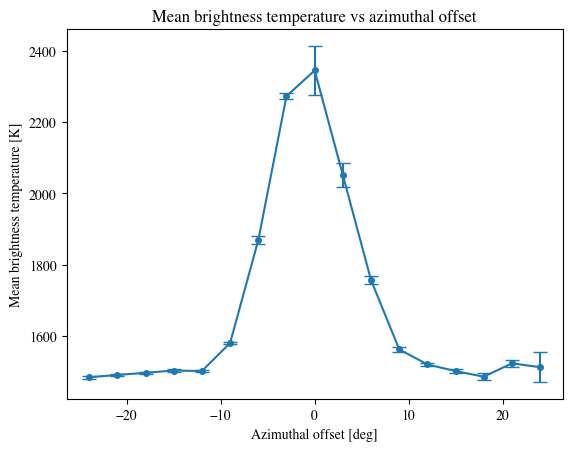

In [17]:
_x = np.linspace(-15, 15, num=100)

plt.errorbar(
    agg_intensities['az_offset'], 
    agg_intensities['mean_intensity'],
    fmt='-o',
    capsize=5,
    markersize=4,
    yerr=agg_intensities['std_intensity']
)

plt.xlabel('Azimuthal offset [deg]')
plt.ylabel('Mean brightness temperature [K]')
plt.title('Mean brightness temperature vs azimuthal offset')

plt.show()

In [18]:
corrected_offset = data.group_by('az_offset').agg(
    pl.col('el').mean()
).with_columns(
    (pl.col('az_offset') * pl.col('el').radians().cos()).alias('corr_offset') # corr_offset <- offset * cos(El)
).sort('az_offset')

corrected_data = agg_intensities.join(corrected_offset, on='az_offset')
corrected_data

az_offset,mean_intensity,std_intensity,el,corr_offset
f64,f64,f64,f64,f64
-24.0,1484.046154,3.584386,48.561538,-15.883566
-21.0,1490.547476,2.545322,48.7,-13.860035
-18.0,1496.458413,3.432754,48.7,-11.88003
-15.0,1502.908594,3.728702,48.758333,-9.888547
-12.0,1501.461058,3.182692,48.8,-7.904274
…,…,…,…,…
12.0,1519.966146,4.328408,49.175,7.84501
15.0,1501.33774,6.010694,49.2,9.801309
18.0,1485.563341,9.954186,49.2,11.761571


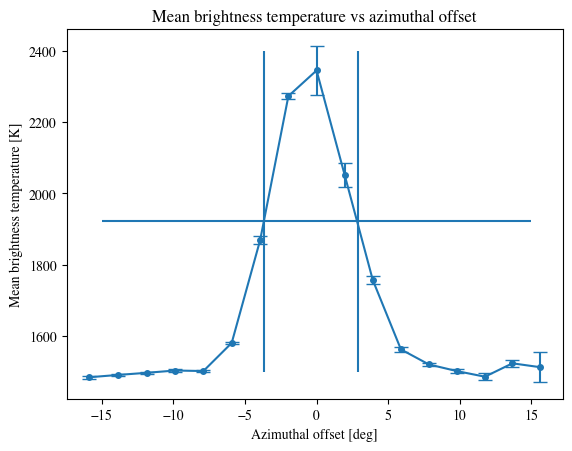

In [19]:
plt.errorbar(
    corrected_data['corr_offset'], 
    corrected_data['mean_intensity'],
    fmt='-o',
    capsize=5,
    markersize=4,
    yerr=corrected_data['std_intensity']
)

plt.hlines(0.5 * (corrected_data['mean_intensity'].max() + 1500), -15, 15)
plt.vlines(-3.7, 1500, 2400)
plt.vlines(2.9, 1500, 2400)

plt.xlabel('Azimuthal offset [deg]')
plt.ylabel('Mean brightness temperature [K]')
plt.title('Mean brightness temperature vs azimuthal offset')

plt.show()

In [20]:
def P(theta):
    wavelength = 0.209645 # Observing wavelength for a 1430.0 MHz frequency, measured in meters
    telescope_diameter = 2.3 # Measured in meters

    x = np.pi * np.sin(np.deg2rad(theta)) / (wavelength / telescope_diameter)
    return (2 * j1(x) / x)**2

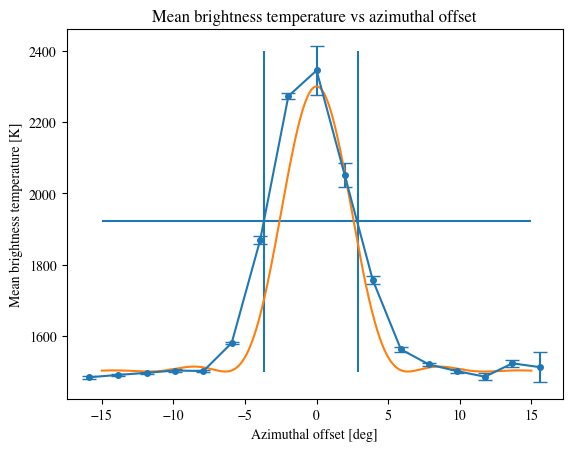

In [21]:
_x = np.linspace(-15, 15, num=500)

plt.errorbar(
    corrected_data['corr_offset'], 
    corrected_data['mean_intensity'],
    fmt='-o',
    capsize=5,
    markersize=4,
    yerr=corrected_data['std_intensity']
)

plt.hlines(0.5 * (corrected_data['mean_intensity'].max() + 1500), -15, 15)
plt.vlines(-3.7, 1500, 2400)
plt.vlines(2.9, 1500, 2400)

plt.plot(_x, 800 * P(_x) + 1500)

plt.xlabel('Azimuthal offset [deg]')
plt.ylabel('Mean brightness temperature [K]')
plt.title('Mean brightness temperature vs azimuthal offset')

plt.show()

## old

In [10]:
spectra = []
frequency = []
counter = 0
file = "lam_lab1_data_30.rad"
infile = open(file)

In [11]:
for line in infile:
    if ('*' not in line[0]):
        print(line)
        line_list = line.strip().split()
        str_spec = line_list[-64:]
        az = float(line_list[3])
        freq = float(line_list[5])
        specific_spec = []
        for item in str_spec:
            specific_spec.append(float(item))
        spectra.append(specific_spec)
infile.close()

In [12]:
for line in infile:
    if ('*' not in line[0]):
        print(line)
        line_list = line.strip().split()
        str_spec = line_list[-64:]
        az = float(line_list[3])
        specific_spec = []
        for item in str_spec:
            specific_spec.append(float(item))
        plt.plot(specific_spec)
        plt.ylabel('Brightness Temperature(K)')
        plt.xlabel('Bin number')
        plt.show()
        spectra.append(specific_spec)
infile.close()

ValueError: I/O operation on closed file.